# Federated Learning Under the Lens of Task Arithmetic

**Project Goal:** Understand FL challenges on pre-trained vision models and explore how Task Arithmetic can help.

**Dataset:** CIFAR-100  
**Model:** DINO ViT-S/16  
**Platform:** Google Colab (Free)

## 0. Setup & Installation

In [2]:
# Install required packages
!pip install -q torch torchvision timm tqdm matplotlib

In [3]:
# Mount Google Drive (optional - for saving checkpoints)
from google.colab import drive
drive.mount('/content/drive')

# Set project root (adjust path as needed)
import sys, os
PROJECT_ROOT = "/content/drive/MyDrive/FL_PROJECT/Federated-Learning-Under-the-Lens-of-Task-Arithmetic"
os.makedirs(PROJECT_ROOT, exist_ok=True)

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(f"✓ Project root: {PROJECT_ROOT}")

Mounted at /content/drive
✓ Project root: /content/drive/MyDrive/FL_PROJECT/Federated-Learning-Under-the-Lens-of-Task-Arithmetic


In [4]:
# Import all necessary modules
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ Using device: {device}")
if device == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

✓ Using device: cuda
  GPU: Tesla T4


## 1. Data Preparation

**Tasks:**
1. Load CIFAR-100
2. Create train/val/test splits
3. Implement IID and Non-IID sharding for FL

In [5]:
# Import data utilities (assuming your code structure)
from data.datasets import get_cifar100, get_cifar100_transforms
from data.partition import make_dataset_loaders
from fl.dataloaders import build_federated_dataloaders

In [6]:
# Get transforms for ViT (default img_size=160 for faster training)
transform_train, transform_test = get_cifar100_transforms(img_size=160)

print("✓ Transforms created")
print(f"  Train: {transform_train}")
print(f"  Test: {transform_test}")

✓ Transforms created
  Train: Compose(
    Resize(size=160, interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)
  Test: Compose(
    Resize(size=160, interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


In [7]:
# Load CIFAR-100 with train/val/test split
train, val, test = get_cifar100(
    train_transform=transform_train,
    test_transform=transform_test,
    val_ratio=0.1,
    root="./data",
    seed=42
)

print(f"✓ CIFAR-100 loaded:")
print(f"  Train: {len(train)} samples")
print(f"  Val:   {len(val)} samples")
print(f"  Test:  {len(test)} samples")

100%|██████████| 169M/169M [00:03<00:00, 43.5MB/s]


✓ CIFAR-100 loaded:
  Train: 45000 samples
  Val:   5000 samples
  Test:  10000 samples


In [8]:
# Create centralized dataloaders (for baseline)
train_loader_centr, val_loader_centr, test_loader_centr = make_dataset_loaders(
    train, val, test
)

print(f"✓ Centralized loaders created")
print(f"  Train batches: {len(train_loader_centr)}")
print(f"  Val batches:   {len(val_loader_centr)}")
print(f"  Test batches:  {len(test_loader_centr)}")

✓ Centralized loaders created
  Train batches: 352
  Val batches:   20
  Test batches:  40


### Test Federated Data Loaders

In [9]:
# Test IID sharding (K=100 clients)
client_loaders_iid, val_loader, test_loader, *_ = build_federated_dataloaders(
    train_transform=transform_train,
    test_transform=transform_test,
    K=100,
    sharding="iid",
    val_ratio=0.1,
    batch_size=64,
    seed=42
)

print(f"✓ IID sharding (K=100):")
print(f"  Number of clients: {len(client_loaders_iid)}")
print(f"  Client 0 batches: {len(client_loaders_iid[0])}")

# Check a batch
xb, yb = next(iter(client_loaders_iid[0]))
print(f"  Batch shape: {xb.shape}, Labels: {yb.shape}")

✓ IID sharding (K=100):
  Number of clients: 100
  Client 0 batches: 8
  Batch shape: torch.Size([64, 3, 160, 160]), Labels: torch.Size([64])


In [10]:
# Test Non-IID sharding with Nc=1 (most extreme heterogeneity)
client_loaders_noniid, _, _, *_ = build_federated_dataloaders(
    train_transform=transform_train,
    test_transform=transform_test,
    K=100,
    sharding="non_iid",
    Nc=1,  # Each client has only 1 class
    val_ratio=0.1,
    batch_size=64,
    seed=42
)

print(f"✓ Non-IID sharding (K=100, Nc=1):")
print(f"  Number of clients: {len(client_loaders_noniid)}")

# Count non-empty clients
non_empty_clients = [i for i, loader in enumerate(client_loaders_noniid) if loader is not None]
print(f"  Non-empty clients: {len(non_empty_clients)}")

# Verify class distribution for first few non-empty clients
checked = 0
for i in range(len(client_loaders_noniid)):
    if client_loaders_noniid[i] is None:
        continue

    labels = []
    for xb, yb in client_loaders_noniid[i]:
        labels.extend(yb.tolist())
    unique_classes = set(labels)
    print(f"  Client {i}: {len(unique_classes)} unique classes - {unique_classes}, {len(labels)} samples")

    checked += 1
    if checked >= 5:  # Show first 5 non-empty clients
        break

✓ Non-IID sharding (K=100, Nc=1):
  Number of clients: 100
  Non-empty clients: 2
  Client 0: 1 unique classes - {73}, 450 samples
  Client 1: 1 unique classes - {73}, 13 samples


## 2. Model Setup

**Task:** Create DINO ViT-S/16 model with classification head

In [11]:
# Import model builder
from models.vit_dino import build_dino_vit

In [12]:
# Create model
model = build_dino_vit(
    num_classes=100,
    img_size=160,
    device=device,
    train_mode=True
)

print("✓ Model created")

# Count parameters
backbone = model[0]
head = model[1]

backbone_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
head_params = sum(p.numel() for p in head.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"  Backbone trainable params: {backbone_params:,}")
print(f"  Head trainable params:     {head_params:,}")
print(f"  Total trainable params:    {total_params:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

✓ Model created
  Backbone trainable params: 21,628,800
  Head trainable params:     38,500
  Total trainable params:    21,667,300


## 3. Phase 0: Sanity Check

**Task:** Quick 1-2 epoch run to verify everything works

In [28]:
# Import training utilities
from train.experiments import phase0_sanity

In [29]:
# Run sanity check (2 epochs)
phase0_res = phase0_sanity(
    train_loader_centr,
    val_loader_centr,
    test_loader_centr,
    epochs=2,
    lr=0.01,
    img_size=160,
    seed=0,
    device=device
)

print("\n✓ Sanity check complete")
print(f"  Final val acc: {phase0_res['best_val_acc']:.4f}")

=== PHASE 0 (sanity) ===

[cosine] Epoch 001/2 ------------------------------
  step 0001/352 | loss 4.8374 acc 0.0078 | 0.4s
  step 0050/352 | loss 4.2569 acc 0.0748 | 16.9s
  step 0100/352 | loss 3.3659 acc 0.2264 | 33.8s
  step 0150/352 | loss 2.7300 acc 0.3545 | 50.2s
  step 0200/352 | loss 2.3356 acc 0.4339 | 66.5s
  step 0250/352 | loss 2.0641 acc 0.4910 | 82.6s
  step 0300/352 | loss 1.8672 acc 0.5329 | 98.9s
  step 0350/352 | loss 1.7164 acc 0.5656 | 115.4s
[cosine] epoch 001 | train loss 1.7123 acc 0.5664 | val loss 0.7112 acc 0.7884 | lr 0.005005

[cosine] Epoch 002/2 ------------------------------
  step 0001/352 | loss 0.5261 acc 0.8359 | 0.3s
  step 0050/352 | loss 0.5566 acc 0.8377 | 15.8s
  step 0100/352 | loss 0.5447 acc 0.8393 | 32.6s
  step 0150/352 | loss 0.5365 acc 0.8416 | 49.9s
  step 0200/352 | loss 0.5243 acc 0.8441 | 66.2s
  step 0250/352 | loss 0.5116 acc 0.8476 | 82.0s
  step 0300/352 | loss 0.5083 acc 0.8477 | 97.8s
  step 0350/352 | loss 0.5048 acc 0.8481 |

## 4. Phase 1: Scheduler Comparison

**Task:** Compare learning rate schedulers (cosine, step, multistep, none)

In [ ]:
from train.experiments import phase1_scheduler_sweep
from utils.plots import plot_test_curves

In [ ]:
# Run scheduler sweep (15 epochs each)
phase1_results, phase1_histories = phase1_scheduler_sweep(
    train_loader_centr,
    val_loader_centr,
    test_loader_centr,
    epochs=15,
    lr=0.03,
    weight_decay=5e-4,
    img_size=160,
    seed=0,
    device=device,
    out_dir=f"{PROJECT_ROOT}/phase1_schedulers",
    save_csv_path=f"{PROJECT_ROOT}/phase1_results.csv"
)

print("\n✓ Phase 1 complete - Results saved to phase1_results.csv")


=== PHASE 1 (scheduler sweep) ===


/content/drive/MyDrive/FL_PROJECT/Federated-Learning-Under-the-Lens-of-Task-Arithmetic/train/experiments.py:69: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.startswith("cuda")))



[cosine] Epoch 001/15 ------------------------------
  step 0001/352 | loss 4.8374 acc 0.0078 | 0.4s
  step 0100/352 | loss 4.2975 acc 0.0548 | 31.5s
  step 0200/352 | loss 3.9191 acc 0.1058 | 63.7s
  step 0300/352 | loss 3.6027 acc 0.1547 | 95.3s
[cosine] epoch 001 | train loss 3.4494 acc 0.1804 | val loss 2.4518 acc 0.3430 | lr 0.029672

[cosine] Epoch 002/15 ------------------------------
  step 0001/352 | loss 2.4242 acc 0.3125 | 0.4s
  step 0100/352 | loss 2.1592 acc 0.4156 | 32.0s
  step 0200/352 | loss 1.9808 acc 0.4566 | 62.4s
  step 0300/352 | loss 1.8559 acc 0.4879 | 92.8s
[cosine] epoch 002 | train loss 1.8052 acc 0.4995 | val loss 1.4571 acc 0.5760 | lr 0.028704

[cosine] Epoch 003/15 ------------------------------
  step 0001/352 | loss 1.4381 acc 0.5938 | 0.4s
  step 0100/352 | loss 1.2063 acc 0.6459 | 32.6s
  step 0200/352 | loss 1.1823 acc 0.6513 | 62.9s
  step 0300/352 | loss 1.1645 acc 0.6578 | 93.3s
[cosine] epoch 003 | train loss 1.1632 acc 0.6578 | val loss 1.1940

KeyboardInterrupt: 

In [ ]:
# Visualize results
plot_test_curves(phase1_histories, title_suffix="(Scheduler Comparison)")

## 5. Phase 2: Hyperparameter Grid Search

**Task:** Grid search over learning rate and weight decay using best scheduler from Phase 1

In [ ]:
from train.experiments import phase2_lr_wd_grid

In [ ]:
# Run grid search (assuming cosine was best)
phase2_results = phase2_lr_wd_grid(
    train_loader_centr,
    val_loader_centr,
    test_loader_centr,
    scheduler_name="cosine",  # Use winner from Phase 1
    epochs=15,
    lr_list=(0.003, 0.005, 0.01, 0.02),
    wd_list=(1e-4, 3e-4, 5e-4, 1e-3),
    img_size=160,
    seed=0,
    device=device,
    out_dir=f"{PROJECT_ROOT}/phase2_grid",
    save_csv_path=f"{PROJECT_ROOT}/phase2_results.csv",
    resume=True  # Allow resuming if interrupted
)

print("\n✓ Phase 2 complete - Results saved to phase2_results.csv")

In [ ]:
# Show top 5 configurations
import pandas as pd

df = pd.DataFrame(phase2_results)
print("\nTop 5 Configurations:")
print(df[['lr', 'weight_decay', 'best_val_acc', 'test_acc']].head())

## 6. Federated Learning - FedAvg Baseline

**Task:** Implement and test FedAvg (McMahan et al., 2017)

**Parameters:**
- K = 100 clients
- C = 0.1 (10% client participation)
- J = 4 local steps
- IID sharding

In [ ]:
# TODO: Import FedAvg implementation
# from fl.fedavg import run_fedavg

print("⚠ FedAvg implementation needed")
print("  This section requires implementing the FedAvg algorithm")

## 7. Heterogeneous Data Distribution

**Task:** Test FedAvg with different Non-IID settings (Nc = 1, 5, 10, 50)

In [17]:
from fl.fedavg import run_fedavg_experiment

import numpy as np
import copy
import matplotlib.pyplot as plt

# Experiment Parameters
K = 100                 # Total clients
C = 0.1                 # Participation (10 clients/round)
Nc_values = [1, 5, 50]  # Heterogeneity levels
J_values = [4, 8, 16]   # Local steps

# NOTE: 40 rounds is very short for CIFAR-100.
# Real convergence usually needs 500+ rounds.
# We use small numbers here just to demonstrate the code runs.
BASE_ROUNDS = 40
BASE_J = 4

all_histories = {}

print("=== Starting Heterogeneity Experiments ===")

# 1. Run Baseline (IID)
# We reuse the client_loaders_iid created in Section 1 if available
if 'client_loaders_iid' not in globals():
    print("Re-creating IID loaders...")
    client_loaders_iid, _, _, *_ = build_federated_dataloaders(
        train_transform=transform_train,
        test_transform=transform_test,
        K=K,
        sharding="iid",
        val_ratio=0.1,
        batch_size=64,
        seed=42
    )

print("\n--- Baseline: IID Data ---")
iid_results = {}
for J in J_values:
    # Scale rounds: if J increases, reduce rounds to keep total compute fixed
    # Example: J=4 -> 40 rounds. J=8 -> 20 rounds.
    scaled_rounds = int(BASE_ROUNDS * (BASE_J / J))

    print(f"\n[Experiment] IID, J={J}, Rounds={scaled_rounds}")
    hist = run_fedavg_experiment(
        model, client_loaders_iid, test_loader_centr,
        rounds=scaled_rounds, C=C, J=J, lr=0.01, device=device, log_every=5
    )
    iid_results[J] = hist
all_histories['iid'] = iid_results

# 2. Run Non-IID Variations
for Nc in Nc_values:
    print(f"\n--- Non-IID: Nc={Nc} (Classes per client) ---")

    # Re-shard data for this specific Nc
    print(f"Generating dataloaders for Nc={Nc}...")

    # FIX: Use *_ to catch extra return values (stats, etc.)
    loaders_noniid, _, _, *_ = build_federated_dataloaders(
        train_transform=transform_train,
        test_transform=transform_test,
        K=K,
        sharding="non_iid",
        Nc=Nc,
        val_ratio=0.1,
        batch_size=64,
        seed=42
    )

    nc_results = {}
    for J in J_values:
        scaled_rounds = int(BASE_ROUNDS * (BASE_J / J))

        print(f"\n[Experiment] Non-IID (Nc={Nc}), J={J}, Rounds={scaled_rounds}")
        hist = run_fedavg_experiment(
            model, loaders_noniid, test_loader_centr,
            rounds=scaled_rounds, C=C, J=J, lr=0.01, device=device, log_every=5
        )
        nc_results[J] = hist

    all_histories[f'Nc={Nc}'] = nc_results

print("\n✓ Experiments Complete")

=== Starting Heterogeneity Experiments ===

--- Baseline: IID Data ---

[Experiment] IID, J=4, Rounds=40
  [FedAvg] Start: 40 rounds, C=0.1 (10 clients), J=4 steps
    Round 005 | Test Acc: 2.92% | Train Loss: 4.7307
    Round 010 | Test Acc: 4.99% | Train Loss: 4.4732
    Round 015 | Test Acc: 6.97% | Train Loss: 4.2997
    Round 020 | Test Acc: 9.73% | Train Loss: 4.1612
    Round 025 | Test Acc: 12.39% | Train Loss: 4.0577
    Round 030 | Test Acc: 14.89% | Train Loss: 3.8783
    Round 035 | Test Acc: 16.60% | Train Loss: 3.8817
    Round 040 | Test Acc: 19.48% | Train Loss: 3.7271

[Experiment] IID, J=8, Rounds=20
  [FedAvg] Start: 20 rounds, C=0.1 (10 clients), J=8 steps
    Round 005 | Test Acc: 2.91% | Train Loss: 4.5989
    Round 010 | Test Acc: 2.94% | Train Loss: 4.3529
    Round 015 | Test Acc: 5.01% | Train Loss: 4.1880
    Round 020 | Test Acc: 4.01% | Train Loss: 4.1071

[Experiment] IID, J=16, Rounds=10
  [FedAvg] Start: 10 rounds, C=0.1 (10 clients), J=16 steps
    Roun

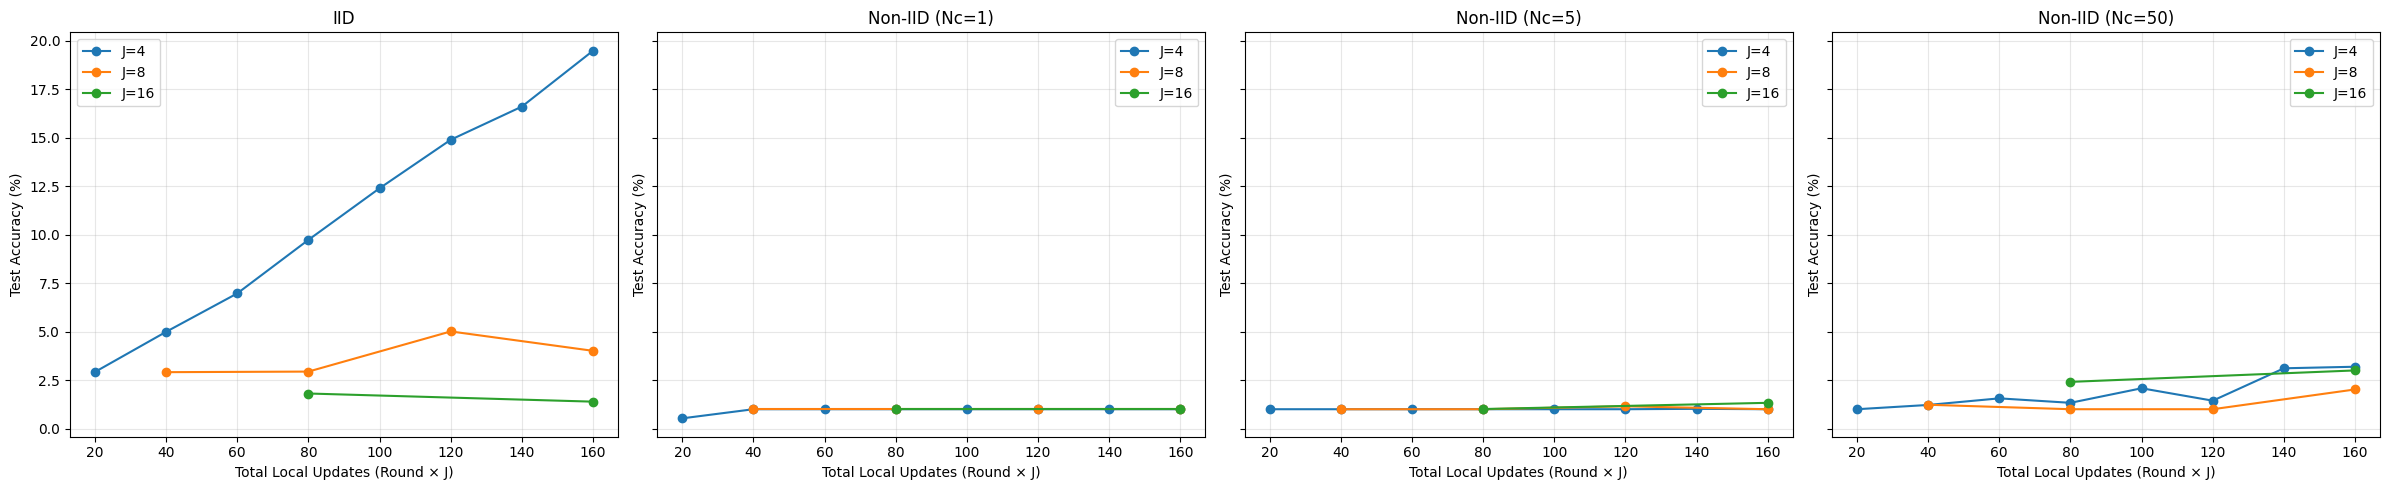

In [18]:
# Visualize the impact of Local Steps (J) across different distributions
fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharey=True)
titles = ["IID"] + [f"Non-IID (Nc={nc})" for nc in Nc_values]
keys = ['iid'] + [f'Nc={nc}' for nc in Nc_values]

for ax, key, title in zip(axes, keys, titles):
    if key not in all_histories: continue

    results = all_histories[key]
    for J, hist in results.items():
        # Plot Accuracy vs. Total Local Updates
        # This normalizes the x-axis so we compare "work done" fairly
        total_updates = [r * J for r in hist['rounds']]
        ax.plot(total_updates, hist['test_acc'], marker='o', label=f'J={J}')

    ax.set_title(title)
    ax.set_xlabel("Total Local Updates (Round × J)")
    ax.set_ylabel("Test Accuracy (%)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Task Arithmetic - Sparse Fine-Tuning

**Task:** Implement sparse SGDM and gradient masking based on Fisher Information

In [ ]:
# Import SparseSGDM optimizer
from optim.sparse_sgd import SparseSGDM

print("✓ SparseSGDM optimizer available")
print("  Next: Implement Fisher Information computation for gradient masking")

In [ ]:
# TODO: Implement Fisher Information computation
# Reference: https://github.com/iurada/talos-task-arithmetic/blob/ae102473de0e57ebf625eca22e10781c371149ec/vision/pruners.py#L203

print("⚠ Fisher Information computation needed")
print("  - Compute diagonal of Fisher Information Matrix")
print("  - Calibrate gradient masks based on sensitivity scores")
print("  - Test with different sparsity ratios")

## 9. Extension Ideas

**Guided Extension Options:**
1. Most-sensitive weights (instead of least-sensitive)
2. Lowest-magnitude weights
3. Highest-magnitude weights
4. Random weights

**Custom Extension:**
- Discuss with TA before implementing

In [ ]:
print("Extension experiments to be implemented based on base results")

## 10. Utilities - Checkpoint Management

In [ ]:
# Function to analyze saved checkpoints
def analyze_checkpoints(base_dir, pattern="cosine_lr"):
    """
    Analyze all checkpoint files matching pattern in base_dir
    """
    import os
    import pandas as pd

    records = []

    for folder in os.listdir(base_dir):
        if not folder.startswith(pattern):
            continue

        folder_path = os.path.join(base_dir, folder)
        if not os.path.isdir(folder_path):
            continue

        # Find best checkpoint
        for fn in os.listdir(folder_path):
            if fn.startswith("best_") and fn.endswith(".pth"):
                ckpt_path = os.path.join(folder_path, fn)
                ckpt = torch.load(ckpt_path, map_location="cpu")

                records.append({
                    "folder": folder,
                    "scheduler": ckpt.get("scheduler", "unknown"),
                    "lr": float(ckpt.get("lr", 0)),
                    "wd": float(ckpt.get("weight_decay", 0)),
                    "best_val_acc": float(ckpt.get("best_val_acc", 0)),
                    "best_epoch": int(ckpt.get("epoch", 0)),
                    "seed": int(ckpt.get("seed", 0)),
                })
                break

    df = pd.DataFrame(records).sort_values("best_val_acc", ascending=False)
    return df.reset_index(drop=True)

print("✓ Checkpoint analysis utility ready")

In [ ]:
# Example: Analyze Phase 2 results
# df = analyze_checkpoints(f"{PROJECT_ROOT}/phase2_grid", pattern="cosine_lr")
# print(df)

## Summary Checklist

**Completed:**
- [ ] Data loading and preprocessing
- [ ] IID/Non-IID sharding implementation
- [ ] Model setup (DINO ViT-S/16)
- [ ] Centralized baseline training
- [ ] Scheduler comparison
- [ ] Hyperparameter search

**To Implement:**
- [ ] FedAvg algorithm
- [ ] Fisher Information computation
- [ ] Sparse fine-tuning with gradient masks
- [ ] Heterogeneity experiments
- [ ] Extension (guided or custom)

**Deliverables:**
- [ ] 8-page LaTeX report
- [ ] Code with README.md
- [ ] All experiments documented